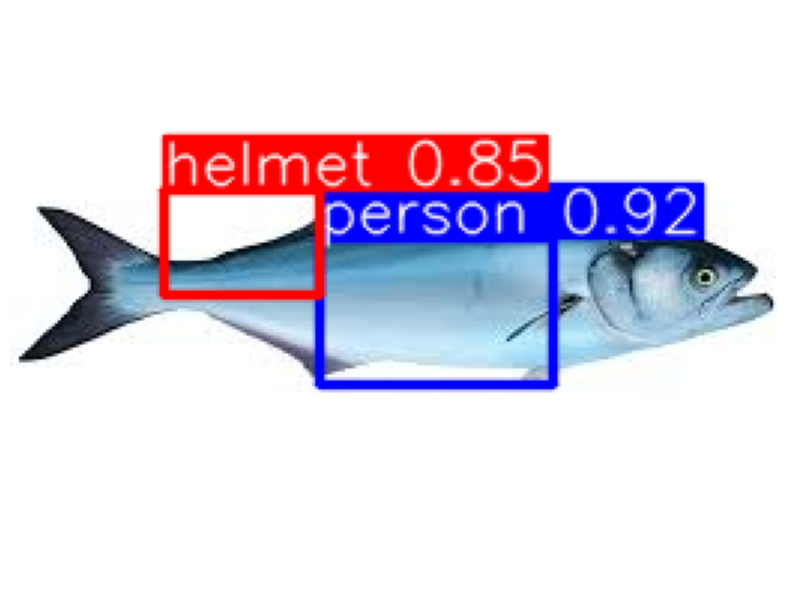

Сохранено как: output_yolo_style.jpg


In [2]:
from ultralytics.utils.plotting import Annotator
import cv2
import matplotlib.pyplot as plt

# ---------- ПУТЬ К ИЗОБРАЖЕНИЮ ----------
image_path = "download.jpg"
img = cv2.imread(image_path)
h, w = img.shape[:2]

# ---------- НАЗВАНИЯ КЛАССОВ ----------
class_names = {
    0: "person",
    1: "helmet"
}

# ---------- КАСТОМНЫЕ ЦВЕТА (BGR) ----------
custom_colors = {
    0: (255, 0, 0),   # person → синий
    1: (0, 0, 255)    # helmet → красный
}

# ---------- ТВОИ РУЧНЫЕ ДЕТЕКЦИИ ----------
# Формат: [cls, conf, x_center, y_center, width, height] (YOLO normalized)
detections = [
    [0, 0.92, 0.55, 0.52, 0.30, 0.25],  # пример person
    [1, 0.85, 0.30, 0.40, 0.20, 0.18],  # пример helmet
]

annotator = Annotator(img)

for cls, conf, x, y, bw, bh in detections:
    # YOLO → пиксели
    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    # текстовая метка: класс + conf
    label = f"{class_names[cls]} {conf:.2f}"

    # цвет класса
    color = custom_colors.get(cls, (0, 255, 0))

    # рисуем как YOLO
    annotator.box_label([x1, y1, x2, y2], label, color=color)

# ---------- СОХРАНЕНИЕ ----------
output_image = "output_yolo_style.jpg"
cv2.imwrite(output_image, annotator.result())

# ---------- ПОКАЗ ЧЕРЕЗ plt ----------
# Конвертируем BGR → RGB
img_rgb = cv2.cvtColor(annotator.result(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

print("Сохранено как:", output_image)
